In [50]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
import pandas as pd 
import seaborn 
import math
from sklearn.linear_model import LinearRegression 
%matplotlib inline

# Гречишкин Денис ПМ-31

# Лабораторная работа №11

# Часть 11.4

## Пример 1

(5.065, 12.434999999999999, 3.57, 10.83)

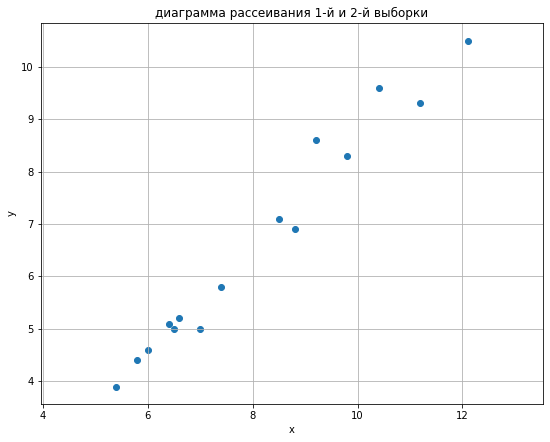

In [51]:
plt.figure(figsize = (9, 7))
xy = np.array([[12.1, 10.5], [11.2, 9.3], [9.8,8.3], [10.4,9.6], [9.2,8.6], [8.5,7.1], [8.8, 6.9], [7.4,5.8], [6.6,5.2], [7.0,5.0], [6.4,5.1], [6.0,4.6], [6.5,5.0], [5.8,4.4], [5.4,3.9] ])
x = xy[:,0].reshape((-1, 1))
y = xy[:,1].T

x1 = xy[:,0]
y1 = xy[:,1]
plt.scatter(x, y)
plt.grid(True)
plt.title("диаграмма рассеивания 1-й и 2-й выборки")
plt.xlabel('x')
plt.ylabel('y')
plt.axis("equal")

In [52]:
linreg = LinearRegression()
linreg.fit(x, y)
print('beta0', linreg.intercept_)
print('beta1', linreg.coef_)
beta0 = linreg.intercept_
beta1 = linreg.coef_
sigmas2 = []
for i in range(len(y1)):
    sigmas2.append((y1[i] - (beta0 + beta1*x1[i]))**2)
s2 = np.var(sigmas2, ddof = 1)
r2 = linreg.score(x, y)
print('s^2', s2)
print('R^2', r2)

beta0 -1.5091257899488406
beta1 [1.00691071]
s^2 0.043073869638201555
R^2 0.9701596485440614


## Пример 2

In [53]:
xy = np.array([[1, 0.5], [1, 0.1], [2, 0.5], [2, 1.2], [3, 1.2], [3, 1.7], [2.7, 0.9], \
               [2.7, 2.2], [4.3, 1.1], [4.3, 1.7], [4.3, 2.5],\
               [5.0, 2.0], [5.0, 2.2]])
x = xy[:,0].reshape((-1, 1))
y = xy[:,1].T
linreg = LinearRegression()
linreg.fit(x, y)
print('свободный член b0:', linreg.intercept_)
print('к-т b1:', linreg.coef_)
R_2 = linreg.score(x, y)
print('к-т детерминации', R_2)

свободный член b0: 0.07130689379824307
к-т b1: [0.41868512]
к-т детерминации 0.6006308212510079


# Часть 11.5(Задания для самостоятельного выполнения)

ВАРИАНТ 7

## Задание 1: Осуществите статистическую обработку двумерной выборки по следующему плану. 
1)  Постройте диаграмму рассеивания, найдите коэффициент корреляции Пирсона; проверьте гипотезу о его значимости (выборки в файле «Данные 11_1» подобраны таким образом, что она должна подтвердиться). 
2)  Составьте уравнения линейной регрессии Y на x и X на y (без использования функций языка программирования Python, непосредственно находящих регрессионные прямые). 
3)  Нанесите графики выборочных прямых на диаграмму рассеивания. 

Проанализируйте полученные результаты с точки зрения их согласованности с другими выборочными характеристиками (центром рассеивания, диаграммой рассеивания, коэффициентом корреляции). 
Для контроля выполните п. 2 задания с помощью соответствующей функции языка программирования Python. 

## Решение: импортируем данные$\newline$ 

In [54]:
DATA11 = pd.read_excel("Data_11_1.xlsx", header = 1, usecols = "N:O")
D11 = pd.DataFrame(DATA11)
#D11 = D11.astype(float)
print(D11)

X = D11['X.6'].astype(str)
Y = D11['Y.6'].astype(str)

X_MASSIV = []
Y_MASSIV = []
for x in X:
    X_MASSIV.append(float(x))
for y in Y:
    if(('–' in y)and(',' in y)):
        y = y.replace('–', '-')
        y = y.replace(',', '.')
    Y_MASSIV.append(float(y))
print('X', X_MASSIV)
print('Y', Y_MASSIV)

      X.6    Y.6
0    6.99  17.26
1   10.40  21.52
2   10.39  13.36
3   15.50  –5,08
4   10.64      5
5    7.83  14.55
6    5.63  17.37
7    8.59  12.49
8   15.75   6.39
9    8.66   5.81
10   8.47  15.83
11   8.74   12.7
12  14.37   0.86
13   5.43  13.14
14  11.77   8.06
15   5.77  17.97
16   6.62   16.5
17   9.13   8.29
18   5.36  11.74
19  20.25  –4,48
20   9.00  13.26
21  15.60   3.36
22   9.92   2.98
23  13.99   8.65
24  14.12  12.11
25  12.32   9.68
26   9.62  15.22
27  11.78   6.83
28  11.75   5.29
29  16.28  –1,24
30  10.58  15.18
31  14.33   6.62
32  10.06  12.36
33   8.48  15.96
34   8.11  14.57
35   6.40  14.68
36  12.37  12.88
37  11.39  10.55
38   2.07  20.85
39   5.91  18.18
40  12.12   8.32
41  10.44   6.97
42  11.11  11.42
43  16.48   4.49
44   7.02  15.15
45   7.66   8.82
46  14.97  –0,59
47  12.15   6.52
48   9.82  16.11
49  12.68  11.42
X [6.99, 10.4, 10.39, 15.5, 10.64, 7.83, 5.63, 8.59, 15.75, 8.66, 8.47, 8.74, 14.37, 5.43, 11.77, 5.77, 6.62, 9.13, 5.36, 20.25, 9.0,

## Пункт 1: выборочный коэффициент корреляции Пирсона найдем по формуле:
$$\rho_{XY} = \frac{\sum_{i = 1}^n (X[i] - \overline{X})\cdot(Y[i] - \overline{Y})}{\sqrt{\sum (X_i - \overline{X})^2 \sum (Y_i - \overline{Y})^2}}$$
Основная гипотеза: $$H_0: \rho = 0$$ Альтернативная гипотеза: $$H_1: \rho \ne 0$$
Возьмем уровень значимости $\alpha = 0.1$
Будем пользоваться критерием, критическая область которого, учитывая введенную альтернативную гипотезу, определяется неравенством: $$|\rho^*| \gt \frac{t_{1-\alpha/2}(n - 2)}{\sqrt{n-2+t_{1-\alpha/2}^2(n - 2)}}$$ 
Далее, см. комментарии в коде

[6.99, 10.4, 10.39, 15.5, 10.64, 7.83, 5.63, 8.59, 15.75, 8.66, 8.47, 8.74, 14.37, 5.43, 11.77, 5.77, 6.62, 9.13, 5.36, 20.25, 9.0, 15.6, 9.92, 13.99, 14.12, 12.32, 9.62, 11.78, 11.75, 16.28, 10.58, 14.33, 10.06, 8.48, 8.11, 6.4, 12.37, 11.39, 2.07, 5.91, 12.12, 10.44, 11.11, 16.48, 7.02, 7.66, 14.97, 12.15, 9.82, 12.68]
10.4964
[17.26, 21.52, 13.36, -5.08, 5.0, 14.55, 17.37, 12.49, 6.39, 5.81, 15.83, 12.7, 0.86, 13.14, 8.06, 17.97, 16.5, 8.29, 11.74, -4.48, 13.26, 3.36, 2.98, 8.65, 12.11, 9.68, 15.22, 6.83, 5.29, -1.24, 15.18, 6.62, 12.36, 15.96, 14.57, 14.68, 12.88, 10.55, 20.85, 18.18, 8.32, 6.97, 11.42, 4.49, 15.15, 8.82, -0.59, 6.52, 16.11, 11.42]
10.3176
к-т пирсона выборок X и Y: -0.7758221087644316
Проверка значимости к-та корреляции Пирсона

Основная гипотеза отклоняется: выборочный к-т корреляции Пирсона статистически значим

0.7758221087644316 > 0.23528993755441346 



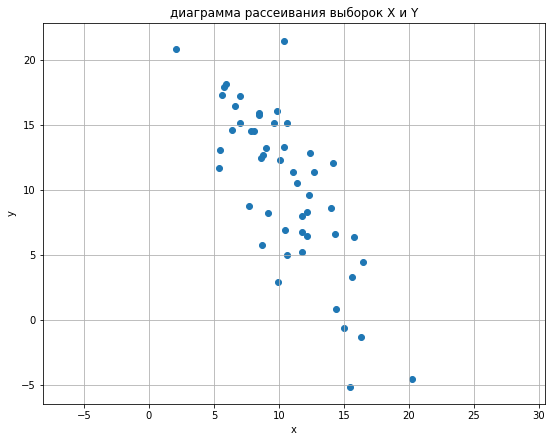

In [55]:
plt.figure(figsize = (9, 7))
plt.scatter(X_MASSIV, Y_MASSIV)
plt.grid(True)
plt.title("диаграмма рассеивания выборок X и Y")
plt.xlabel('x')
plt.ylabel('y')
plt.axis("equal")

mx = np.mean(X_MASSIV)
print(X_MASSIV)
print(mx)
my = np.mean(Y_MASSIV)
print(Y_MASSIV)
print(my)
chisl = 0
sumx = 0
sumy = 0
for i in range(len(X_MASSIV)):
    chisl += (X_MASSIV[i] - mx)*(Y_MASSIV[i] - my)
    sumx += (X_MASSIV[i] - mx)**2
    sumy += (Y_MASSIV[i] - my)**2
ro_pirsona = chisl/(np.sqrt(sumx*sumy))
print('к-т пирсона выборок X и Y:', ro_pirsona)

print("Проверка значимости к-та корреляции Пирсона\n")
n = len(X_MASSIV)
alpha = 0.1
prav_chasch_ner_va = ((sts.t(n-2)).ppf(1-alpha/2))/(np.sqrt(n-2+((sts.t(n-2)).ppf(1-alpha/2))**2))
if(np.abs(ro_pirsona) > prav_chasch_ner_va):
    print("Основная гипотеза отклоняется: выборочный к-т корреляции Пирсона статистически значим\n")
    print(np.abs(ro_pirsona), ">", prav_chasch_ner_va, "\n")
else:
    print("Основная гипотеза принимается: выборочный к-т корреляции Пирсона статистически не значим\n")
    print(np.abs(ro_pirsona), "<=", prav_chasch_ner_va, "\n")

## Пункт 2
P.S. Этот пункт делал по формулам линейной регрессии из лекции №16.
Далее задания я делал по формулам из задачника, где используются к-ты $\tilde{\beta_1}$ и $\tilde{\beta_0}$ (они также используются в проверке через питоновские функции)

In [56]:
Dx = np.var(X_MASSIV, ddof = 0)
Dy = np.var(Y_MASSIV, ddof = 0)
sigma_x = np.sqrt(Dx)
sigma_y = np.sqrt(Dy)
kx = (ro_pirsona*sigma_y)/sigma_x
bx = -mx*(ro_pirsona*sigma_y)/sigma_x + my

ky = (ro_pirsona*sigma_x)/sigma_y
by = -my*(ro_pirsona*sigma_x)/sigma_y + mx

XY = []
for i in range(len(X_MASSIV)):
    XY.append([X_MASSIV[i], Y_MASSIV[i]])
XY = np.array(XY)
X1 = XY[:,0].reshape((-1, 1))
Y1 = XY[:,1].T
Y2 = XY[:,1].reshape((-1, 1))
X2 = XY[:,0].T

print('Уравнение линейной регрессии Y на X: \n Y =', kx, "* ( X - ",mx,") +", my)
print('преобразованный вид линейной регрессии Y на X\n', kx, "* X +", kx*(-mx)+my, "\n")

print('Уравнение линейной регрессии X на Y: \n X =', ky, "* ( Y - ",my,") +", mx)
print('преобразованный вид линейной регрессии Y на X\n', ky, "* Y +", ky*(-my)+mx, "\n")

print("Проверка к-тов линейной регрессии Y на X")
linreg = LinearRegression()
linreg.fit(X1, Y1)
print('beta0', linreg.intercept_)
print('beta1', linreg.coef_)

print("Проверка к-тов линейной регрессии X на Y")
linreg = LinearRegression()
linreg.fit(Y2, X2)
print('beta0', linreg.intercept_)
print('beta1', linreg.coef_)

Уравнение линейной регрессии Y на X: 
 Y = -1.3316299440319315 * ( X -  10.4964 ) + 10.3176
преобразованный вид линейной регрессии Y на X
 -1.3316299440319315 * X + 24.294920544536765 

Уравнение линейной регрессии X на Y: 
 X = -0.4520024103883146 * ( Y -  10.3176 ) + 10.4964
преобразованный вид линейной регрессии Y на X
 -0.4520024103883146 * Y + 15.159980069422474 

Проверка к-тов линейной регрессии Y на X
beta0 24.294920544536765
beta1 [-1.33162994]
Проверка к-тов линейной регрессии X на Y
beta0 15.159980069422474
beta1 [-0.45200241]


Видно что все к-ты посчитаны правильно

## Пункт 3

Text(0.5, 1.0, 'Диаграмма рассеивания с линиями регрессии')

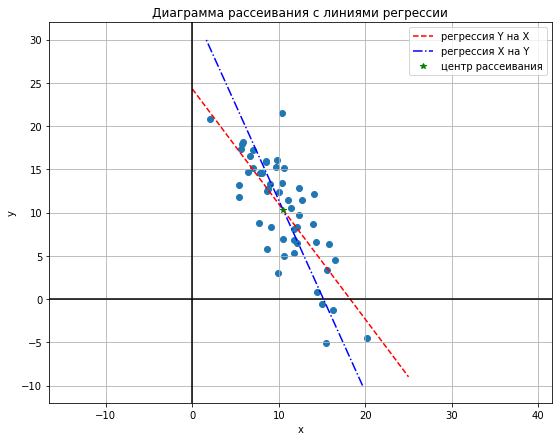

In [57]:
plt.figure(figsize = (9, 7))
plt.scatter(X_MASSIV, Y_MASSIV)
plt.grid(True)
plt.title("диаграмма рассеивания выборок X и Y")
plt.xlabel('x')
plt.ylabel('y')
plt.axis("equal")

X = np.linspace(0, 25, 1000)
Y = kx*(X - mx) + my

y = np.linspace(-10, 30, 1000)
x = ky*(y - my) + mx

plt.plot(X, Y, '--r', label = 'регрессия Y на X')
plt.plot(x, y, '-.b', label = 'регрессия X на Y')
plt.plot(mx, my, '*g', label = 'центр рассеивания')
plt.legend()
plt.axhline(y = 0, color = 'k')
plt.axvline(x = 0, color = 'k')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Диаграмма рассеивания с линиями регрессии')

**ВЫВОДЫ**: из графика видно что центр рассеивания совпадает с точкой пересечения графиков линейных регрессий, точки диаграммы рассеивания находятся близко к графикам, а выборочный к-т корреляции показывает, что элементы двух выборок связаны друг с другом, причем эта связь достаточно близка к линейной. К тому же знак к-та корреляции совпадает с расположением точек на плоскости и углом наклона линий регрессии

$\newline$

## Задание 2: В предположении, что ошибки наблюдений не коррелированы и имеют нормальное распределение $N(0, \sigma)$, оцените качество аппроксимации результатов наблюдения уравнением линейной регрессии Y на X: 
1)  вычислите оценку $S^2$ для дисперсии ошибок наблюдений $\sigma^2$; 
2)  найдите коэффициент детерминации $R^2$; 
3)  постройте доверительные интервалы для параметров регрессии; 
4)  постройте доверительный интервал для дисперсии ошибок наблюдений $\sigma^2$; 
5)  постройте доверительные интервалы для среднего значения Y при $x = x_0$ и визуализируйте их (на рисунок с диаграммой рассеивания и регрессионными прямыми нанесите графики зависимости левой и правой границ доверительных интервалов от значения  $x = x_0$).   
6)  проверьте статистическую значимость линейной регрессии Y на x на уровне значимости 0,05. 


Все расчеты пп. 1 – 6 выполните с непосредственным использованием формул. 

## Решение

## Пункт 1. Воспользуемся формулой 
$$S^2 = \frac{Q_e}{n - 2} = \frac{1}{n - 2}\sum[y_i - (\beta_0 + \beta_1 x_i)]^2$$

In [58]:
def LinRegYonX(x):
    return kx*(x - mx) + my
mx = np.mean(X_MASSIV)
my = np.mean(Y_MASSIV)


Qy = 0
Qx = 0
Qxy = 0

for i in range(len(Y_MASSIV)):
    #Qe += (Y_MASSIV[i] - LinRegYonX(X_MASSIV[i]))**2
    Qy += (Y_MASSIV[i] - my)**2
    #Qr += (LinRegYonX(X_MASSIV[i]) - my)**2
for i in range(len(X_MASSIV)):
    Qx += (X_MASSIV[i] - mx)**2
    Qxy += (X_MASSIV[i] - mx)*(Y_MASSIV[i] - my)
    
Qr = ((Qxy)**2)/Qx
Qe = Qy - Qr

print('Qe', Qe)
print('Qr', Qr)
print('Qx', Qx)
print('Qy', Qy)
print('Qxy', Qxy)

#п1
S2 = Qe/(n-2)
print('ПУНКТ 1\n')
print('Q_e =', Qe)
print('S^2 =', S2)

Qe 741.7301952108933
Qr 1121.4451167891064
Qx 632.4277519999999
Qy 1863.1753119999996
Qxy -842.1597320000001
ПУНКТ 1

Q_e = 741.7301952108933
S^2 = 15.452712400226943


## Пункт 2.
Воспользуемся формулой
$$R^2 = \frac{Q_R}{Q_y}$$
Где
$$Q_R = \sum ((\beta_0 + \beta_1 x_i) - \overline{y})^2$$
$$Q_R = \sum (y_i - \overline{y})^2$$

In [59]:
#п2
R = Qr/Qy
print('ПУНКТ 2\n')
print('Q_y =', Qy)
print('Q_r =', Qr)
print('R^2 =', R)

ПУНКТ 2

Q_y = 1863.1753119999996
Q_r = 1121.4451167891064
R^2 = 0.6018999444476895


## Пункт 3. Воспользуемся формулами из номера 19.322 задачника. Возьмем уровень значимости $\alpha = 0.1$

In [60]:
alpha = 0.1
n = len(X_MASSIV)
beta_1_vib = Qxy/Qx
beta_0_vib = my - beta_1_vib*mx
print('знвчение выборочного beta0:', beta_0_vib)
print('знвчение выборочного beta1:', beta_1_vib)
sum_x_massiv2 = 0
for i in range(len(X_MASSIV)):
    sum_x_massiv2 += X_MASSIV[i]**2

prav_gr_beta_0 = beta_0_vib + (sts.t(n-2)).ppf(1 - alpha/2)*np.sqrt(S2)*np.sqrt((sum_x_massiv2)/(n*Qx))
lev_gr_beta_0 = beta_0_vib - (sts.t(n-2)).ppf(1 - alpha/2)*np.sqrt(S2)*np.sqrt((sum_x_massiv2)/(n*Qx))
prav_gr_beta_1 = beta_1_vib + (sts.t(n-2)).ppf(1 - alpha/2)*np.sqrt(S2)*np.sqrt(1/(Qx))
lev_gr_beta_1 = beta_1_vib - (sts.t(n-2)).ppf(1 - alpha/2)*np.sqrt(S2)*np.sqrt(1/(Qx))
print('ПУНКТ 3\n')
print('доверительнй интервал для beta0\n')
print(lev_gr_beta_0, '< beta_0 <', prav_gr_beta_0, '\n')
print('доверительнй интервал для beta1\n')
print(lev_gr_beta_1, '< beta_1 <', prav_gr_beta_1)

знвчение выборочного beta0: 24.294920544536765
знвчение выборочного beta1: -1.3316299440319312
ПУНКТ 3

доверительнй интервал для beta0

21.389374153053012 < beta_0 < 27.20046693602052 

доверительнй интервал для beta1

-1.5938029780994678 < beta_1 < -1.0694569099643947


## Пункт 4. Воспользуемся формулами из номера 19.323 задачника. Возьмем уровень значимости $\alpha = 0.1$

In [61]:
alpha = 0.1
n = len(X_MASSIV)
beta_1_vib = Qxy/Qx
beta_0_vib = my - beta_1_vib*mx

lev_gr_sigma = ((n-2)*s2)/(sts.chi2(n-2).ppf(1-alpha/2))
prav_gr_sigma = ((n-2)*s2)/(sts.chi2(n-2).ppf(alpha/2))
print('ПУНКТ 4\n')
print('доверительнй интервал для sigma^2\n')
print(lev_gr_sigma, '< sigma^2 <', prav_gr_sigma, '\n')

ПУНКТ 4

доверительнй интервал для sigma^2

0.031725047554570465 < sigma^2 < 0.0624672459310808 



## Пункт 5. Доверительный интервал для $Y_0$:
$$\tilde{y_0} - t_{1-\alpha/2}(n - 2)s\sqrt{\frac{1}{n} + \frac{(x_0 - \overline{x})}{Q_x}} < Y_0 < \tilde{y_0} + t_{1-\alpha/2}(n - 2)s\sqrt{\frac{1}{n} + \frac{(x_0 - \overline{x})}{Q_x}}$$

50
21.389374153053012
27.20046693602052


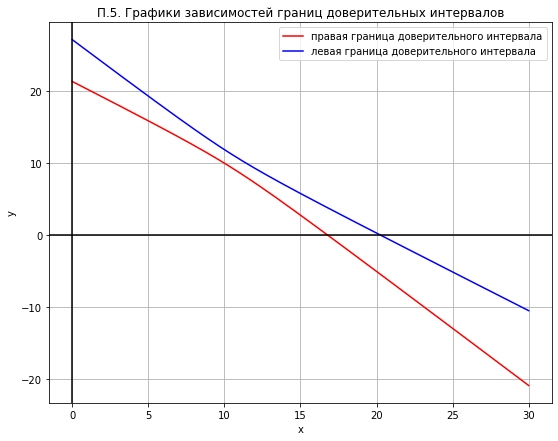

In [70]:
y0w0 = LinRegYonX(0)

alpha = 0.1
n = len(X_MASSIV)

levaya_granitsa_0 = y0w0 - ((sts.t(n - 2)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(1/n + (0 - mx)**2/Qx)
pravaya_granitsa_0 = y0w0 + ((sts.t(n - 2)).ppf(1-alpha/2))*np.sqrt(S2)*np.sqrt(1/n + (0 - mx)**2/Qx)

x0 = np.linspace(0, 30, 1000)
y0w = LinRegYonX(x0)
levaya_granitsa = y0w - sts.t(n - 2).ppf(1-alpha/2)*np.sqrt(S2)*np.sqrt(1/n + (x0 - mx)**2/Qx)
pravaya_granitsa = y0w + sts.t(n - 2).ppf(1-alpha/2)*np.sqrt(S2)*np.sqrt(1/n + (x0 - mx)**2/Qx)

plt.figure(figsize = (9, 7))
plt.plot(x0, levaya_granitsa, '-r', label = 'правая граница доверительного интервала')
plt.plot(x0, pravaya_granitsa, '-b', label = 'левая граница доверительного интервала')
plt.grid(True)
plt.title('П.5. Графики зависимостей границ доверительных интервалов')
plt.axhline(y = 0, color = 'k')
plt.axvline(x = 0, color = 'k')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
print(n)
print(levaya_granitsa_0)
print(pravaya_granitsa_0)

## Пункт 6 $\newline$
1. Основная гипотеза: $$H_0: \rho = 0$$ Альтернативная гипотеза $$H_1: \rho \ne 0$$
2. $\alpha = 0.05$
3. $$Z = \frac{arth \rho_{XY}^* - arth \rho_{XY}}{1/\sqrt{n-3}} \approx N(0, 1)$$ Статистика считается приблизительно нормально распределенной при $n \le 30$. В нашем случае так можно считать, поскольку $n = 50$
4. $$G_{\alpha} = \left\{|Z| > u_{1-\alpha/2}\right\}$$

In [63]:
Alpha = 0.05
n = len(X_MASSIV)
Z_sel = (math.atanh(ro_pirsona) - math.atanh(0))/(1/(np.sqrt(n - 3)))
print('Выборочное значение статистики', Z_sel)
if(np.abs(Z_sel) > sts.norm(0, 1).ppf(1-Alpha/2)):
    print('Основная гипотеза отклоняется, выборочн. к-т корреляции является значимым')
    print(np.abs(Z_sel), '<=', sts.norm(0, 1).ppf(1-Alpha/2))
else:
    print('Основная гипотеза принимается, выборочн. к-т корреляции не является значимым')
    print(np.abs(Z_sel), '>', sts.norm(0, 1).ppf(1-Alpha/2))

Выборочное значение статистики -7.0941589181822975
Основная гипотеза отклоняется, выборочн. к-т корреляции является значимым
7.0941589181822975 <= 1.959963984540054


$\newline$

## Задание 3: Для изучения вопроса об адекватности построенной модели проанализируйте остатки (выборку значений случайных ошибок наблюдений – разностей между наблюдаемыми значениями $y_i$ и вычисленными по регрессионному уравнению $\tilde{y}$, i = 1,2,...,n). Постройте график зависимости остатков от $x_j$, постройте гистограмму выборки значений случайных ошибок наблюдений, проверьте гипотезу о распределении ошибок наблюдений по нормальному закону.

Замечание. При проведении регрессионного анализа считают, что случайные ошибки наблюдений имеют нулевое математическое ожидание, одинаковую дисперсию, попарно некоррелированы и распределены по нормальному закону (и, следовательно, являются независимыми случайными величинами). Подтверждение перечисленных свойств остатков говорит в пользу правильности построенной модели. 

## Решение:

Text(0.5, 1.0, 'гистограмма разностей (взятых по модулю)')

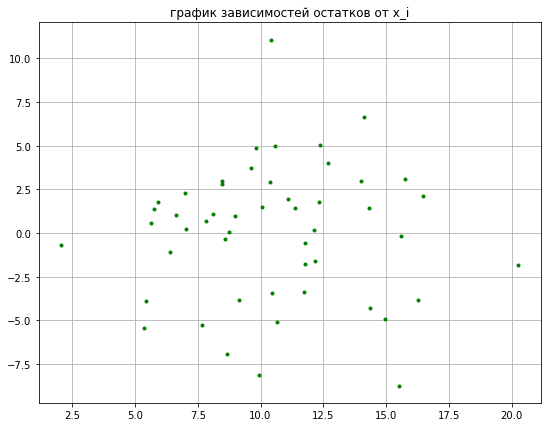

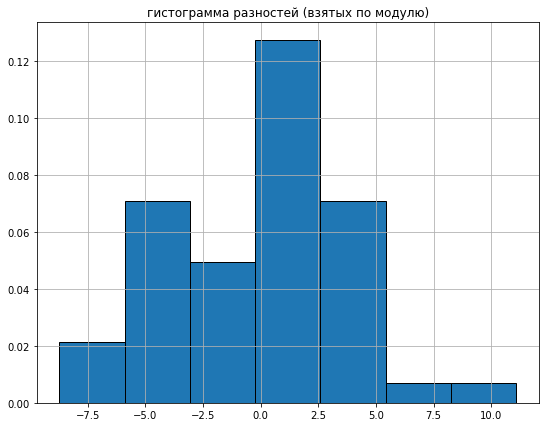

In [64]:
def LinRegYonX(x):
    return kx*(x - mx) + my
errors = []

for i in range(len(Y_MASSIV)):
    errors.append(Y_MASSIV[i] - LinRegYonX(X_MASSIV[i]))
    
plt.figure(figsize = (9, 7))
plt.plot(X_MASSIV, errors, '.g')
plt.grid(True)
plt.title("график зависимостей остатков от x_i")

plt.figure(figsize = (9, 7))
plt.hist(errors, bins = 'sturges', edgecolor = 'black', density = True)
plt.grid(True)
plt.title("гистограмма разностей (взятых по модулю)")

Проверим нормальность выборки ошибок по критерию Шапиро-Уилка

In [65]:
errors_proverka = sts.shapiro(errors)
print('выборочное значение статистики', errors_proverka.statistic)
print('значение p-value', errors_proverka.pvalue)
print('на уровне значимости alpha <', errors_proverka.pvalue, 'гипотеза о нормальности распределения ошибок принимается')
print('на уровне значимости alpha >=', errors_proverka.pvalue, 'гипотеза о нормальности распределения ошибок отклоняется')

выборочное значение статистики 0.9759606122970581
значение p-value 0.39677825570106506
на уровне значимости alpha < 0.39677825570106506 гипотеза о нормальности распределения ошибок принимается
на уровне значимости alpha >= 0.39677825570106506 гипотеза о нормальности распределения ошибок отклоняется


$\newline$

## Задание 4 (ИСПРАВЛЕННОЕ): Сгруппируйте данные по x и проверьте адекватность линейной регрессии Y на x на уровне значимости 0,05. Данные группировки по x выведите на печать. 

## Решение: для начала сгруппируем данные

(1.1609999999999998, 21.159, -6.41, 22.85)

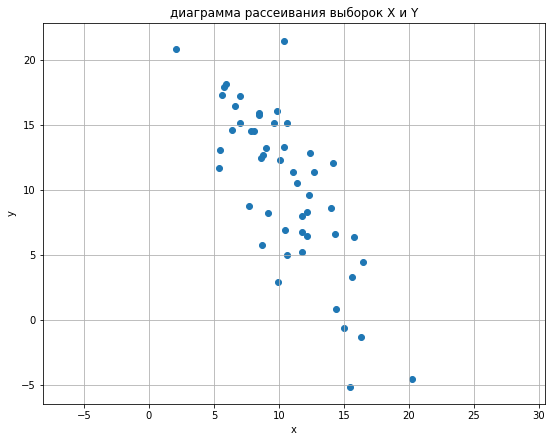

In [66]:
plt.figure(figsize = (9, 7))
plt.scatter(X_MASSIV, Y_MASSIV)
plt.grid(True)
plt.title("диаграмма рассеивания выборок X и Y")
plt.xlabel('x')
plt.ylabel('y')
plt.axis("equal")

Группировать данные по X будем по диаграмме выше. Возьмем шаг $\Delta = 5$

In [72]:
xy = []
delta = 5
for i in range(len(X_MASSIV)):
    xy.append({'x_i':X_MASSIV[i], 'y_i':Y_MASSIV[i]})
grs_x = [0+5*i for i in range(0, 6)]
grs_y = [-10+5*i for i in range(0, 8)]
mids_x = [(grs_x[i-1]+grs_x[i])/2 for i in range(1, len(grs_x))]
mids_y = [(grs_y[i-1]+grs_y[i])/2 for i in range(1, len(grs_y))]
print('Массив X_i:', mids_x)

Массив X_i: [2.5, 7.5, 12.5, 17.5, 22.5]


In [73]:
arr_with_elements = [[] for _ in range(len(mids_x))]
#matr_with_amount
for i in range(len(xy)):
    for j in range(len(mids_x)):
        if (((xy[i]['x_i'] > (mids_x[j] - delta/2)) and (xy[i]['x_i'] < (mids_x[j] + delta/2)))):
            arr_with_elements[j].append(xy[i]['y_i'])
arr_with_lens = [len(subarray) for subarray in arr_with_elements]
mas_overline_ys_i = [np.mean(subarray) for subarray in arr_with_elements]
print('группированные элементы по X\n')
for i in range(len(mids_x)):
    print('X_i =', mids_x[i])
    print(arr_with_elements[i])
    print('Длина массива:', arr_with_lens[i])
    print('SEL_Y_i =', mas_overline_ys_i[i], '\n')

группированные элементы по X

X_i = 2.5
[20.85]
Длина массива: 1
SEL_Y_i = 20.85 

X_i = 7.5
[17.26, 14.55, 17.37, 12.49, 5.81, 15.83, 12.7, 13.14, 17.97, 16.5, 8.29, 11.74, 13.26, 2.98, 15.22, 15.96, 14.57, 14.68, 18.18, 15.15, 8.82, 16.11]
Длина массива: 22
SEL_Y_i = 13.57181818181818 

X_i = 12.5
[21.52, 13.36, 5.0, 0.86, 8.06, 8.65, 12.11, 9.68, 6.83, 5.29, 15.18, 6.62, 12.36, 12.88, 10.55, 8.32, 6.97, 11.42, -0.59, 6.52, 11.42]
Длина массива: 21
SEL_Y_i = 9.190952380952378 

X_i = 17.5
[-5.08, 6.39, 3.36, -1.24, 4.49]
Длина массива: 5
SEL_Y_i = 1.584 

X_i = 22.5
[-4.48]
Длина массива: 1
SEL_Y_i = -4.48 



Проверим линейную регрессию на адекватность. Для того чтобы это сделать, воспользуемся статистикой:
$$G = \frac{Q_n/(m - 2)}{Q_p/(n - m)}$$
распределенной по закону Фишера с параметрами $m - 2$, $n - m$ 
Здесь: $$Q_n = \sum_{i=1}^m n_i(\overline{y_i} - \tilde{y_i})^2$$ где $$\overline{y_i} = \frac{1}{n_i}\sum_{j=1}^{n_i} y_{ij}$$
А также: 
$$Q_p = \sum_{i=1}^m \sum_{j=1}^{n_i} (y_{ij} - \overline{y_i})^2$$


In [74]:
def LinRegYonX(x):
    return kx*(x - mx) + my
alpha = 0.05
Q_n = 0
Q_p = 0
m = len(mids_x)
n = len(xy)
for i in range(m):
    Q_n += arr_with_lens[i]*(mas_overline_ys_i[i] - LinRegYonX(mids_x[i]))**2

for i in range(m):
    for j in range(arr_with_lens[i]):
        Q_p += (arr_with_elements[i][j] - mas_overline_ys_i[i])**2

g_sel = (Q_n/(m-2))/((Q_p)/(n-m))
print('Выборочное значение статистики G:', g_sel, '\n')
if(g_sel < (sts.f(m-2, n-m)).ppf(1-alpha)):
    print("Гипотеза об адекватности линейной регрессии результатам наблюдений принимается")
    print(g_sel, '<', (sts.f(m-2, n-m)).ppf(1-alpha))
else:
    print("Гипотеза об адекватности линейной регрессии результатам наблюдений отклоняется")
    print(g_sel, '>=', (sts.f(m-2, n-m)).ppf(1-alpha))

Выборочное значение статистики G: 1.0924877048656934 

Гипотеза об адекватности линейной регрессии результатам наблюдений принимается
1.0924877048656934 < 2.811543506332673
